# CS 6220 Data Mining Homework 01
**Name:** Rutuja Jadhav



## Import the libraries

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.6.1


- `time` — measures training/testing duration.
- `numpy`, `pandas` — handle numeric arrays and tabular data.
- `matplotlib.pyplot` — plots scatterplots and the confusion matrix.
- `load_iris` — loads the Iris dataset.
- `train_test_split` — splits data into train/test sets.
- `Pipeline`, `StandardScaler` — build and scale the ML pipeline.
- `LogisticRegression` — classifier used for prediction.
- `accuracy_score`, `confusion_matrix`, `ConfusionMatrixDisplay` — evaluate model performance.

## Load the Iris Dataset

We load it via scikit-learn's built-in `load_iris`, which is the same dataset published by UCI, so no separate download step is needed.

In [3]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df['species'] = np.array(iris.target_names)[iris.target]

print(df.shape)
df.head()

(150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


- `load_iris(as_frame=True)` — loads Iris data as a pandas DataFrame.
- `iris.frame` — contains the 4 features plus numeric target column.
- `df['species']` — maps numeric target to actual species names.
- `df.shape` — confirms 150 rows, 6 columns.
- `df.head()` — previews the first 5 rows.

## Exploratory Scatterplots

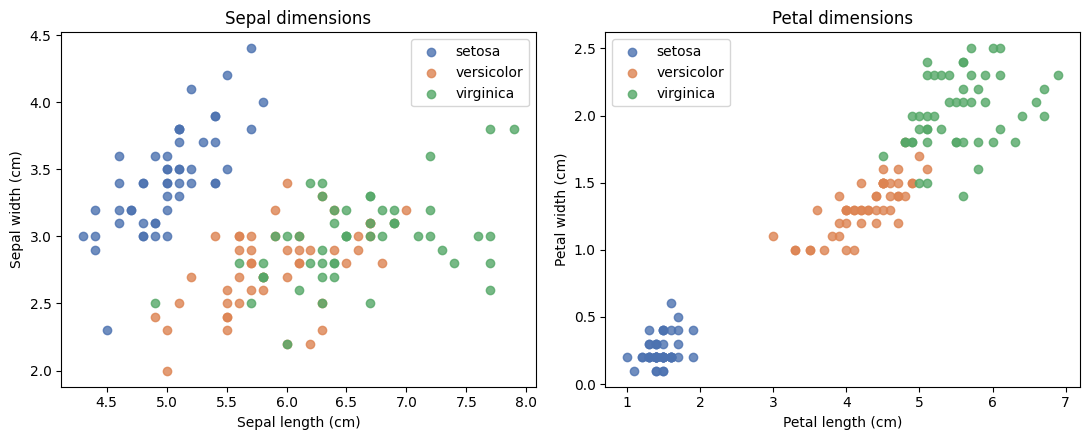

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors = {'setosa': '#4C72B0', 'versicolor': '#DD8452', 'virginica': '#55A868'}

for sp, c in colors.items():
    sub = df[df['species'] == sp]
    axes[0].scatter(sub['sepal length (cm)'], sub['sepal width (cm)'], label=sp, color=c, alpha=0.8)
    axes[1].scatter(sub['petal length (cm)'], sub['petal width (cm)'], label=sp, color=c, alpha=0.8)

axes[0].set_xlabel('Sepal length (cm)'); axes[0].set_ylabel('Sepal width (cm)')
axes[0].set_title('Sepal dimensions'); axes[0].legend()
axes[1].set_xlabel('Petal length (cm)'); axes[1].set_ylabel('Petal width (cm)')
axes[1].set_title('Petal dimensions'); axes[1].legend()
plt.tight_layout()
plt.show()

- `plt.subplots(1, 2, ...)` — creates two side-by-side plots.
- Loop over species — filters rows per species and scatters sepal/petal dimensions.
- `axes[0]` — sepal length vs width plot.
- `axes[1]` — petal length vs width plot.

## Train and Test Split


In [6]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (120, 4)  Test shape: (30, 4)


- `X = iris.data` — the 4 numeric features (inputs).
- `y = iris.target` — the species labels (0, 1, 2) to predict.
- `random_state=42` — makes the split reproducible.
- `stratify=y` — keeps the same class proportions in both train and test sets.

## Build the scikit-learn Pipeline

In [7]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=200))
])
pipeline

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=200))])

- `Pipeline([...])` — combines preprocessing and model into one step.
- `StandardScaler()` — scales features before training.
- `LogisticRegression(max_iter=200)` — the classifier used.
- `pipeline` — shows the pipeline structure.

A Pipeline chains preprocessing and modeling into one object, so calling fit/predict automatically scales data using train-set stats first, then feeds it to the classifier — preventing test-data leakage.

## Train the Model

In [8]:
start_train = time.perf_counter()
pipeline.fit(X_train, y_train)
end_train = time.perf_counter()

train_time = end_train - start_train
print(f"Training time: {train_time:.6f} seconds")

Training time: 0.080818 seconds


- `time.perf_counter()` — records a precise timestamp before and after training.
- `pipeline.fit(X_train, y_train)` — trains the scaler and classifier on training data.
- `train_time` — the difference between start and end gives training duration.

## Evaluate the Model

In [9]:
start_test = time.perf_counter()
y_pred = pipeline.predict(X_test)
end_test = time.perf_counter()

test_time = end_test - start_test
accuracy = accuracy_score(y_test, y_pred)

print(f"Testing time: {test_time:.6f} seconds")
print(f"Test accuracy: {accuracy:.4f}")

Testing time: 0.010241 seconds
Test accuracy: 0.9333


- `pipeline.predict(X_test)` — scales test data and predicts species labels.
- `test_time` — measures how long prediction takes.
- `accuracy_score(y_test, y_pred)` — compares predictions to true labels.

## Confusion Matrix

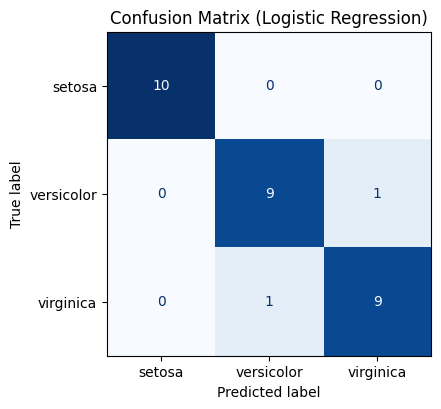

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)

fig2, ax2 = plt.subplots(figsize=(4.5, 4.5))
disp.plot(ax=ax2, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix (Logistic Regression)')
plt.tight_layout()
plt.show()

- `confusion_matrix(y_test, y_pred)` — counts correct/incorrect predictions per class.
- `ConfusionMatrixDisplay` — builds a plot from the matrix.
- `disp.plot(...)` — renders the confusion matrix as a heatmap.

## Hyperparameter Exploration

In [12]:
print("Logistic Regression — accuracy vs. C:")
for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
    lr_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=200, C=C))
    ])
    lr_pipe.fit(X_train, y_train)
    lr_acc = accuracy_score(y_test, lr_pipe.predict(X_test))
    print(f"  C={C:>6}: accuracy={lr_acc:.4f}")

Logistic Regression — accuracy vs. C:
  C=  0.01: accuracy=0.8000
  C=   0.1: accuracy=0.8667
  C=   1.0: accuracy=0.9333
  C=  10.0: accuracy=1.0000
  C= 100.0: accuracy=1.0000


- Loop over `C` values — tests different regularization strengths.
- New `Pipeline` each time — trains a fresh model per `C`.
- `accuracy_score(...)` — records test accuracy for each `C`.